In [43]:
#PRincipal finding program 

In [44]:
##Finding the area of a rectangle 

from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [45]:
class mystate(TypedDict):
    p : float
    r : float
    t : float
    si : float

In [46]:
graph = StateGraph(mystate)

def si(state : mystate) -> dict :
    p = state['p']
    r = state['r']
    t = state['t']
    state['si'] = (p*r*t)/100
    return state

In [47]:
#adding node 
graph.add_node("si", si)

In [48]:
#add edge
graph.add_edge(START,"si")
graph.add_edge("si",END)

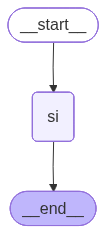

In [49]:
graph.compile()

In [50]:
comp = graph.compile()

In [51]:
result = comp.invoke({"p":1000,"r":5,"t":2})

In [52]:
print([result])

[{'p': 1000, 'r': 5, 't': 2, 'si': 100.0}]


In [53]:
##Finding the area of a rectangle 

from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

class chatstate(TypedDict):
    user_msg : str
    category : str
    response : str



def route_by_category(state: chatstate) -> Literal["technical", "billing", "general"]:
    """
    State mein category dekhke decide karo kahan jaana hai
    Yeh function sirf routing decision leta hai — koi state update nahi
    """
    return state.get("category", "general")

def classify_node(state : chatstate)->dict:
    msg = state["user_msg"].lower()
    if any(w in msg for w in ["error", "bug", "crash", "api", "technical"]):
        return {"category": "technical"}
    elif any(w in msg for w in ["bill", "payment", "invoice", "refund"]):
        return {"category": "billing"}
    else:
        return {"category": "general"}


def technical_node(state : chatstate)->dict:
    return {"response": f"[Technical] '{state['user_msg']}' - Tech Team will investigate "}


def billing_node(state : chatstate)->dict:
    return {"response": f"[Billing] '{state['user_msg']}' - Please share the account id "}


def general_node(state : chatstate)->dict:
    return {"response": f"[General] '{state['user_msg']}' - Happy to help! "}



In [54]:
graph = StateGraph(chatstate)
graph.add_node("classify", classify_node)
graph.add_node("technical", technical_node)
graph.add_node("billing", billing_node)
graph.add_node("general",general_node)

In [55]:
graph.add_edge(START, "classify")
graph.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "technical": "technical",
        "billing":   "billing",
        "general":   "general",
    }

)
graph.add_edge("technical", END)
graph.add_edge("billing", END)
graph.add_edge("general", END)

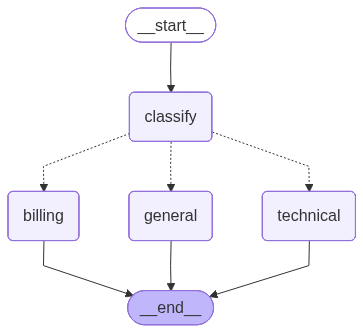

In [56]:
graph.compile()

In [61]:
comp = graph.compile()
result = comp.invoke({"user_msg": "What happened to my refund"})
print(result["response"])

[Billing] 'What happened to my refund' - Please share the account id 
